<a href="https://colab.research.google.com/github/akashmavle5/--akash/blob/main/Notebook5_Educational_MCAIXI_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 5 — Educational MC-AIXI-Style Agent

This capstone notebook combines the ideas from the previous notebooks into
one educational agent.

Included:
- Bayesian beliefs
- Universal-mixture style model averaging
- Context-based prediction
- Monte Carlo planning
- Multiple environments
- Benchmarking
- Learning curves

> This is **not** an implementation of the mathematically exact AIXI or
MC-AIXI-CTW algorithms. It is a compact educational approximation inspired by
their architecture.


In [1]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

random.seed(99)
np.random.seed(99)


## Environments

In [2]:
class Bandit:
    def __init__(self):
        self.probs=[0.2,0.5,0.8]
    def reset(self):
        return 0
    def step(self,a):
        r=1 if random.random()<self.probs[a] else 0
        return 0,r,False

class Grid:
    ACTIONS=["U","D","L","R"]
    def __init__(self):
        self.goal=(4,4)
        self.reset()
    def reset(self):
        self.pos=(0,0)
        return self.pos
    def clone(self):
        g=Grid()
        g.goal=self.goal
        g.pos=self.pos
        return g
    def step(self,a):
        x,y=self.pos
        if a==0:x=max(0,x-1)
        elif a==1:x=min(4,x+1)
        elif a==2:y=max(0,y-1)
        elif a==3:y=min(4,y+1)
        self.pos=(x,y)
        r=-1
        d=False
        if self.pos==self.goal:
            r=25
            d=True
        return self.pos,r,d


## Universal Mixture

In [3]:
class Hypothesis:
    def __init__(self,name,length,bias):
        self.name=name
        self.length=length
        self.bias=bias

H=[
Hypothesis("Simple",1,0.9),
Hypothesis("Explorer",2,1.0),
Hypothesis("Greedy",2,1.2),
Hypothesis("Optimist",3,1.4)
]

class Mixture:
    def __init__(self):
        p=np.array([2**(-h.length) for h in H],float)
        self.posterior=p/p.sum()

    def update(self,reward):
        like=[]
        for h in H:
            mu=max(0.1,h.bias*reward)
            like.append(math.exp(-abs(reward-mu)))
        like=np.array(like)
        self.posterior*=like+1e-12
        self.posterior/=self.posterior.sum()

    def value(self,x):
        return float(np.dot(self.posterior,[h.bias*x for h in H]))


## Context Predictor

In [4]:
class ContextPredictor:
    def __init__(self):
        self.counts={}
    def update(self,history,symbol):
        key=tuple(history[-3:])
        if key not in self.counts:
            self.counts[key]=[1,1]
        self.counts[key][symbol]+=1
    def predict(self,history):
        key=tuple(history[-3:])
        if key not in self.counts:
            return 0.5,0.5
        c=self.counts[key]
        s=sum(c)
        return c[0]/s,c[1]/s


## Monte Carlo Planner

In [5]:
def rollout(env,depth=6):
    world=env.clone()
    total=0
    gamma=0.95
    for i in range(depth):
        _,r,d=world.step(random.randint(0,3))
        total+=(gamma**i)*r
        if d:
            break
    return total

def choose_action(env):
    vals=[]
    for a in range(4):
        sims=[]
        for _ in range(40):
            w=env.clone()
            _,r,d=w.step(a)
            v=r
            if not d:
                v+=rollout(w)
            sims.append(v)
        vals.append(np.mean(sims))
    return int(np.argmax(vals)),vals


## Unified Educational Agent

In [6]:
class MCAIXIAgent:
    def __init__(self):
        self.mix=Mixture()
        self.ctx=ContextPredictor()
        self.history=[]
    def observe_reward(self,r):
        self.mix.update(r)
        self.ctx.update(self.history,1 if r>0 else 0)
        self.history.append(1 if r>0 else 0)
    def predict_reward_probability(self):
        return self.ctx.predict(self.history)


## Grid Benchmark

In [7]:
env=Grid()
agent=MCAIXIAgent()

env.reset()

curve=[]

reward_sum=0

for step in range(35):
    a,vals=choose_action(env)
    s,r,d=env.step(a)
    reward_sum+=r
    curve.append(reward_sum)
    agent.observe_reward(r)
    p0,p1=agent.predict_reward_probability()
    print(step,s,r,"Posterior",np.round(agent.mix.posterior,3),"P(success)",round(p1,3))
    if d:
        print("Goal reached")
        break


0 (0, 0) -1 Posterior [0.444 0.222 0.222 0.111] P(success) 0.5
1 (0, 0) -1 Posterior [0.444 0.222 0.222 0.111] P(success) 0.5
2 (0, 0) -1 Posterior [0.444 0.222 0.222 0.111] P(success) 0.5
3 (0, 0) -1 Posterior [0.444 0.222 0.222 0.111] P(success) 0.333
4 (0, 0) -1 Posterior [0.444 0.222 0.222 0.111] P(success) 0.25
5 (0, 0) -1 Posterior [0.444 0.222 0.222 0.111] P(success) 0.2
6 (0, 0) -1 Posterior [0.444 0.222 0.222 0.111] P(success) 0.167
7 (0, 0) -1 Posterior [0.444 0.222 0.222 0.111] P(success) 0.143
8 (0, 0) -1 Posterior [0.444 0.222 0.222 0.111] P(success) 0.125
9 (0, 0) -1 Posterior [0.444 0.222 0.222 0.111] P(success) 0.111
10 (0, 0) -1 Posterior [0.444 0.222 0.222 0.111] P(success) 0.1
11 (0, 0) -1 Posterior [0.444 0.222 0.222 0.111] P(success) 0.091
12 (0, 0) -1 Posterior [0.444 0.222 0.222 0.111] P(success) 0.083
13 (0, 0) -1 Posterior [0.444 0.222 0.222 0.111] P(success) 0.077
14 (0, 0) -1 Posterior [0.444 0.222 0.222 0.111] P(success) 0.071
15 (0, 0) -1 Posterior [0.444 0

## Multi-Armed Bandit Benchmark

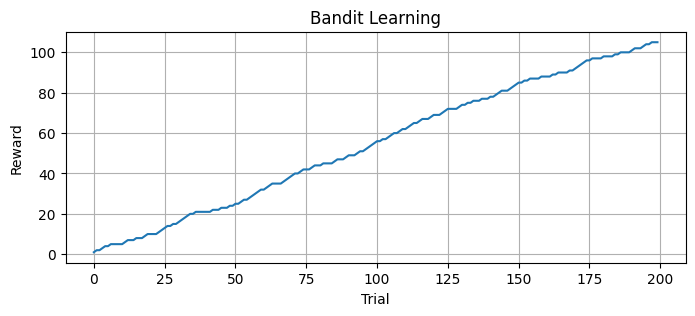

In [8]:
bandit=Bandit()
agent=MCAIXIAgent()

tot=[]

reward=0

for t in range(200):
    arm=random.randint(0,2)
    _,r,_=bandit.step(arm)
    reward+=r
    agent.observe_reward(r)
    tot.append(reward)

plt.figure(figsize=(8,3))
plt.plot(tot)
plt.grid()
plt.title("Bandit Learning")
plt.xlabel("Trial")
plt.ylabel("Reward")
plt.show()


## Learning Curve

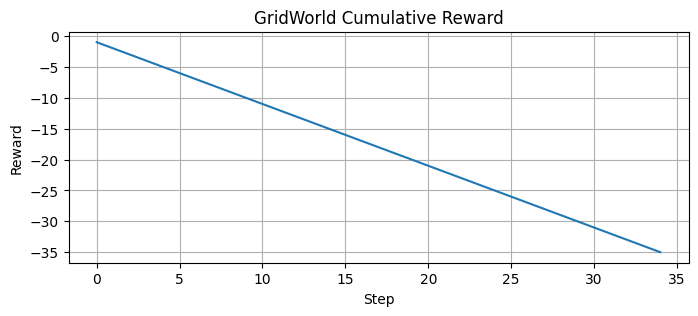

In [9]:
plt.figure(figsize=(8,3))
plt.plot(curve)
plt.grid()
plt.title("GridWorld Cumulative Reward")
plt.xlabel("Step")
plt.ylabel("Reward")
plt.show()


## Posterior Beliefs

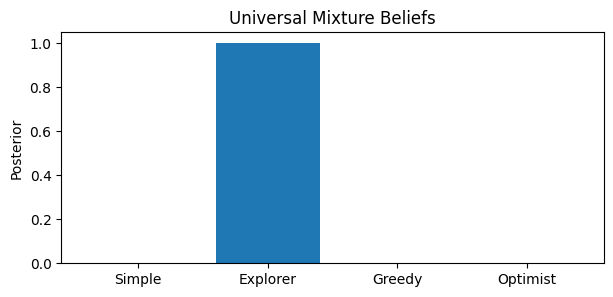

In [10]:
plt.figure(figsize=(7,3))
plt.bar([h.name for h in H],agent.mix.posterior)
plt.ylabel("Posterior")
plt.title("Universal Mixture Beliefs")
plt.show()


# Final Summary

Across the five notebooks you have implemented educational approximations of:

| Topic | Notebook |
|---|---|
| Agent/environment interaction | 1 |
| Bayesian learning | 1 |
| Occam priors | 1 |
| Solomonoff-inspired induction | 2 |
| Universal mixtures | 2 |
| MDL | 2 |
| Monte Carlo planning | 3 |
| Expectimax | 3 |
| Context-based prediction | 4 |
| Entropy & information gain | 4 |
| Integrated MC-AIXI-style agent | 5 |

The real AIXI and MC-AIXI-CTW algorithms are substantially more sophisticated,
but this series provides a practical framework for understanding how the major
ideas fit together.
